# Gal4M Tutorial 1 — Codecs: tokenizing each modality

A multimodal transformer (Tutorial 2) operates on **discrete integer tokens**, not
raw floats. A **codec** is the bridge: it maps one modality to a short sequence of
tokens and back.

```
        ENCODE                         DECODE
raw  ──►  _encode  ──►  quantizer.encode  ──►  tokens (ints)
                                                  │
tokens ──► quantizer.decode ──► _decode ──► reconstruction
```

![Codec: encode to tokens, decode back](assets/Image-codec.png)

Every codec exposes the same two methods (`aion.codecs.base.Codec`):

* `codec.encode(modality) -> LongTensor[B, n_tokens]`
* `codec.decode(tokens)   -> modality`

The art is **choosing the right codec family** for each data type. Gal4M uses three:

| Family | Used for | Why |
|--------|----------|-----|
| **2-D MagVit VQ-AE + FSQ** | galaxy face-on image | a conv encoder/decoder captures 2-D spatial structure; many tokens (32×32) |
| **1-D ConvNeXt VQ-AE + LFQ** | SFH, gas/DM profiles | smooth low-dimensional curves compress to a handful of tokens |
| **Scalar quantile quantizer** | the 8 scalars | a single number → 1 ordinal token; no neural net needed |

This tutorial trains on the **multi-redshift** set — 19,118 galaxies across five
snapshots (z = 0.0 → 0.4) — and validates on a fair, held-out 500-galaxy set
(100 per redshift).

## How this notebook is meant to be run

The neural codecs (SFH, profiles, and especially the galaxy image) are **trained**
here, which needs a GPU. So the notebook runs in two passes, switched by the
`GAL4M_TRAIN` environment variable:

1. **Load pass (default).** Run the notebook normally. The training cells are
   **skipped**; each codec is **loaded** from `checkpoints/codecs/` and we
   **demonstrate its reconstruction** on the held-out, multi-redshift validation
   set. This runs on a laptop.
2. **Train pass (GPU).** Set `GAL4M_TRAIN=1`. The training cells then run the
   *same* per-step procedure inline. (The published checkpoints were produced this
   way — `python -m sim.train_codecs` over all five snapshots, ~3 h on one V100,
   keeping the best-by-validation checkpoint for each codec.)

The `TRAIN` flag below reads `GAL4M_TRAIN`.

**One normalization, shared everywhere.** The star-image normalization is a
*fixed* constant (`img_norm.json`, computed once on a fair sample of training
images) applied identically to the training set, the validation set, and
downstream tokenization. Using a fixed normalization — rather than recomputing it
per batch — keeps every galaxy on the same scale, so the codec always sees
in-distribution inputs.

> **Data & checkpoints.** This notebook pulls its data and pre-trained
> checkpoints from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial) — each file downloads
> automatically on first use (into `data/` and `checkpoints/`). To fetch
> everything up front instead, run
> `from sim.hub import download_data, download_checkpoints; download_data(); download_checkpoints()`.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
%matplotlib inline

from sim.hub import (DATA_DIR, CHECKPOINTS_DIR,   # local-first; auto-downloads from the HF Hub
                     data_path, checkpoint_path)

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# TRAIN pass (GPU) vs. LOAD pass (default). See the markdown above.
TRAIN = os.environ.get("GAL4M_TRAIN", "0") == "1"

TRAIN_FILES = [os.path.join(DATA_DIR, f"Snap{s}.npz") for s in (72, 78, 84, 91, 99)]
VAL_FILE    = data_path("val.npz")                   # 500 held-out gal (from the HF Hub)
SAVE_DIR    = CHECKPOINTS_DIR                         # -> checkpoints/codecs/<modality>/
VOCAB_SCALAR = 1024                                  # scalar codebook size

# Fixed train-set image normalization, shared by train / val / tokenization.
with open(data_path("img_norm.json")) as f:
    _norm = json.load(f)
IMG_NORM = {"median": _norm["median"], "iqr": _norm["iqr"]}

# Hyper-parameters for the inline TRAIN pass.
EPOCHS_1D  = 100;  BATCH_1D  = 64
EPOCHS_IMG = 60;   BATCH_IMG = 8;  LR_IMG = 1e-4
N_TOK      = 64                    # galaxies tokenized in the final token-dict demo

print(f"device={DEVICE}   TRAIN={TRAIN}   img_norm={IMG_NORM}")

device=cuda   TRAIN=False   img_norm={'median': 7.5859375, 'iqr': 4.05078125}


In [2]:
from sim.dataset import GalaxyDataset
from sim.modalities import (
    SIM_BANDS, SimGalaxyImage,
    SimSFH, SimGasProfile, SimDMProfile,
    SimSFR, SimMstar, SimMhalo, SimR200, SimMbh, SimEgyRM, SimRMpow, SimRedshift,
)

# Held-out validation set: 500 galaxies, 100 per redshift (z=0.0-0.4), fair-sampled.
# The SAME fixed IMG_NORM is applied here as during training -> in-distribution images.
val_ds = GalaxyDataset([VAL_FILE], normalize_images=True, img_norm=IMG_NORM)
zred = np.round(1.0 / val_ds.scale_factor.numpy() - 1.0, 2)
# one representative galaxy per redshift for the reconstruction panels
reps = [int(np.where(zred == zz)[0][0]) for zz in sorted(set(zred.tolist()))]

if TRAIN:
    # The full multi-redshift training set (19,118 galaxies across 5 snapshots).
    train_ds = GalaxyDataset(TRAIN_FILES, normalize_images=True, img_norm=IMG_NORM)
    print(f"train={len(train_ds)}  val={len(val_ds)}  redshifts={sorted(set(zred.tolist()))}")
else:
    train_ds = None
    print(f"LOAD pass: val={len(val_ds)} galaxies  redshifts={sorted(set(zred.tolist()))}")

# Fixed axes shared by all galaxies (needed by the 1-D codecs on decode).
time_grid   = val_ds.sfh[0, 0, :].clone()
radius_grid = val_ds.gas_prof[0, 0, :].clone()

LOAD pass: val=500 galaxies  redshifts=[0.0, 0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]


## Training & loading helpers

Two small training loops (1-D and 2-D image) and one loader. Both trainers evaluate the
reconstruction MSE on the **held-out multi-redshift val set** every epoch and save the
codec **only when it improves** — so the checkpoint on disk is the best model, not the
last one. Each trainer takes the train tensor `Xtr` and the val tensor `Xva` explicitly
(train comes from the 5 snapshots, val from `val.npz`).

In [3]:
def load_codec(codec, modality):
    '''Load the best saved checkpoint for a codec into `codec`.'''
    w = checkpoint_path(f"codecs/{modality.name}/pytorch_model.bin")
    codec.load_state_dict(torch.load(w, map_location=DEVICE, weights_only=True))
    return codec.to(DEVICE).eval()

@torch.no_grad()
def _val_mse_1d(codec, Xva, Mod):
    codec.eval()
    z = codec._encode(Mod(value=Xva)); z_q, _, _ = codec.quantizer(z); xh = codec._decode(z_q)
    return F.mse_loss(xh.value[:, 1:2, :], Xva[:, 1:2, :]).item()

def train_1d_codec(codec, Xtr, Xva, Mod, modality, epochs, title):
    '''Train a 1-D LFQ codec; save the best-val checkpoint to disk. Returns val-MSE history.'''
    codec = codec.to(DEVICE)
    Xtr = Xtr.to(DEVICE); Xva = Xva.to(DEVICE)
    opt = AdamW(codec.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    best = float("inf"); hist = []
    for ep in range(epochs):
        codec.train()
        perm = torch.randperm(len(Xtr), device=DEVICE)
        for i in range(0, len(Xtr), BATCH_1D):
            xb = Xtr[perm[i:i+BATCH_1D]]
            z = codec._encode(Mod(value=xb)); z_q, lfq, _ = codec.quantizer(z); xh = codec._decode(z_q)
            loss = F.mse_loss(xh.value[:, 1:2, :], xb[:, 1:2, :]) + 0.1 * lfq
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(codec.parameters(), 1.0); opt.step()
        sched.step()
        vmse = _val_mse_1d(codec, Xva, Mod); hist.append(vmse)
        if vmse < best:
            best = vmse; codec.save_pretrained(SAVE_DIR, modality=modality)
        if ep == 0 or (ep + 1) % 25 == 0:
            print(f"  {title} epoch {ep+1:3d}/{epochs}  val MSE={vmse:.4f}  (best={best:.4f})")
    print(f"  {title}: best val MSE = {best:.4f}  -> saved")
    return hist

def train_image_codec(codec, Xtr, Xva, modality, epochs, title):
    '''Train the MagVit image codec; save the best-val checkpoint to disk.'''
    codec = codec.to(DEVICE)
    opt = AdamW(codec.parameters(), lr=LR_IMG, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    best = float("inf"); hist = []
    for ep in range(epochs):
        codec.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(perm), BATCH_IMG):
            xb = Xtr[perm[i:i+BATCH_IMG]].to(DEVICE)
            z = codec._encode(SimGalaxyImage(flux=xb, bands=SIM_BANDS))
            z_q, _, _ = codec.quantizer(z); xh = codec._decode(z_q)
            loss = F.mse_loss(xh.flux, xb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(codec.parameters(), 1.0); opt.step()
        sched.step()
        codec.eval(); vt = 0.0; nb = 0
        with torch.no_grad():
            for i in range(0, len(Xva), BATCH_IMG):
                xb = Xva[i:i+BATCH_IMG].to(DEVICE)
                z = codec._encode(SimGalaxyImage(flux=xb, bands=SIM_BANDS))
                z_q, _, _ = codec.quantizer(z); xh = codec._decode(z_q)
                vt += F.mse_loss(xh.flux, xb).item(); nb += 1
        vmse = vt / nb; hist.append(vmse)
        if vmse < best:
            best = vmse; codec.save_pretrained(SAVE_DIR, modality=modality)
        print(f"  {title} epoch {ep+1:3d}/{epochs}  val MSE={vmse:.4f}  (best={best:.4f})")
    print(f"  {title}: best val MSE = {best:.4f}  -> saved")
    return hist

## Family C — Scalars: a quantile "codec" with no neural net

A scalar like `log M_halo` is a single number. We turn it into one integer token
with a **quantile (CDF) quantizer** (`ScalarReservoirQuantizer`):

1. **Calibrate** — stream the training values through a reservoir to estimate the
   empirical cumulative distribution function (CDF).
2. **Encode** — `token = round(CDF(value) * (vocab-1))`. Equal-probability bins, so
   the codebook spends resolution where the data actually live.
3. **Decode** — map the bin back to its representative value.

Because adjacent bins hold adjacent values, the tokens are **ordinal** — which is
why `sim/modality_info.py` marks the scalar modalities `is_ordinal=True`. Some
fields have an explicit "non-detection" floor (e.g. quenched galaxies at very low
SFR); the factory re-bases that floor so it does not waste resolution
(`make_sfr_codec(..., floor=-4.0)`, `make_egyRM_codec(..., floor=-2.0)`).

Calibration is instantaneous and needs **no GPU**, so on the TRAIN pass we
calibrate all **8 scalars** (sfr, mstar, mhalo, r200, mbh, egyRM, RMpow, redshift)
on the training split and save; on the LOAD pass we load the saved checkpoints. We
use `codebook_size=1024` for every scalar.

In [4]:
from sim.codecs.scalars import (
    make_sfr_codec, make_mstar_codec, make_mhalo_codec, make_r200_codec,
    make_mbh_codec, make_egyRM_codec, make_RMpow_codec, make_redshift_codec,
)

# modality name -> (factory, modality class, val_ds attribute, label)
scalar_specs = {
    "sim_sfr":      (make_sfr_codec,      SimSFR,      "sfr0",         r"$\log$ SFR"),
    "sim_mstar":    (make_mstar_codec,    SimMstar,    "m4s",          r"$\log M_\star$"),
    "sim_mhalo":    (make_mhalo_codec,    SimMhalo,    "mhs",          r"$\log M_{\rm halo}$"),
    "sim_r200":     (make_r200_codec,     SimR200,     "r200",         r"$\log r_{200}$"),
    "sim_mbh":      (make_mbh_codec,      SimMbh,      "mbh",          r"$\log M_{\rm bh}$"),
    "sim_egyRM":    (make_egyRM_codec,    SimEgyRM,    "egyRM",        "egyRM"),
    "sim_RMpow":    (make_RMpow_codec,    SimRMpow,    "RMpow",        "RMpow"),
    "sim_redshift": (make_redshift_codec, SimRedshift, "scale_factor", "scale factor"),
}

scalar_codecs = {}
for name, (mk, Mod, attr, lab) in scalar_specs.items():
    codec = mk(VOCAB_SCALAR)
    if TRAIN:
        codec.calibrate(getattr(train_ds, attr))            # empirical CDF on the train split
        codec.save_pretrained(SAVE_DIR, modality=codec.modality)
    else:
        w = os.path.join(SAVE_DIR, "codecs", name, "pytorch_model.bin")
        codec.load_state_dict(torch.load(w, map_location="cpu", weights_only=True))
    scalar_codecs[name] = codec
print(("calibrated + saved" if TRAIN else "loaded"), "scalar codecs:", list(scalar_codecs))

/home/yueyingn/.conda/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded scalar codecs: ['sim_sfr', 'sim_mstar', 'sim_mhalo', 'sim_r200', 'sim_mbh', 'sim_egyRM', 'sim_RMpow', 'sim_redshift']


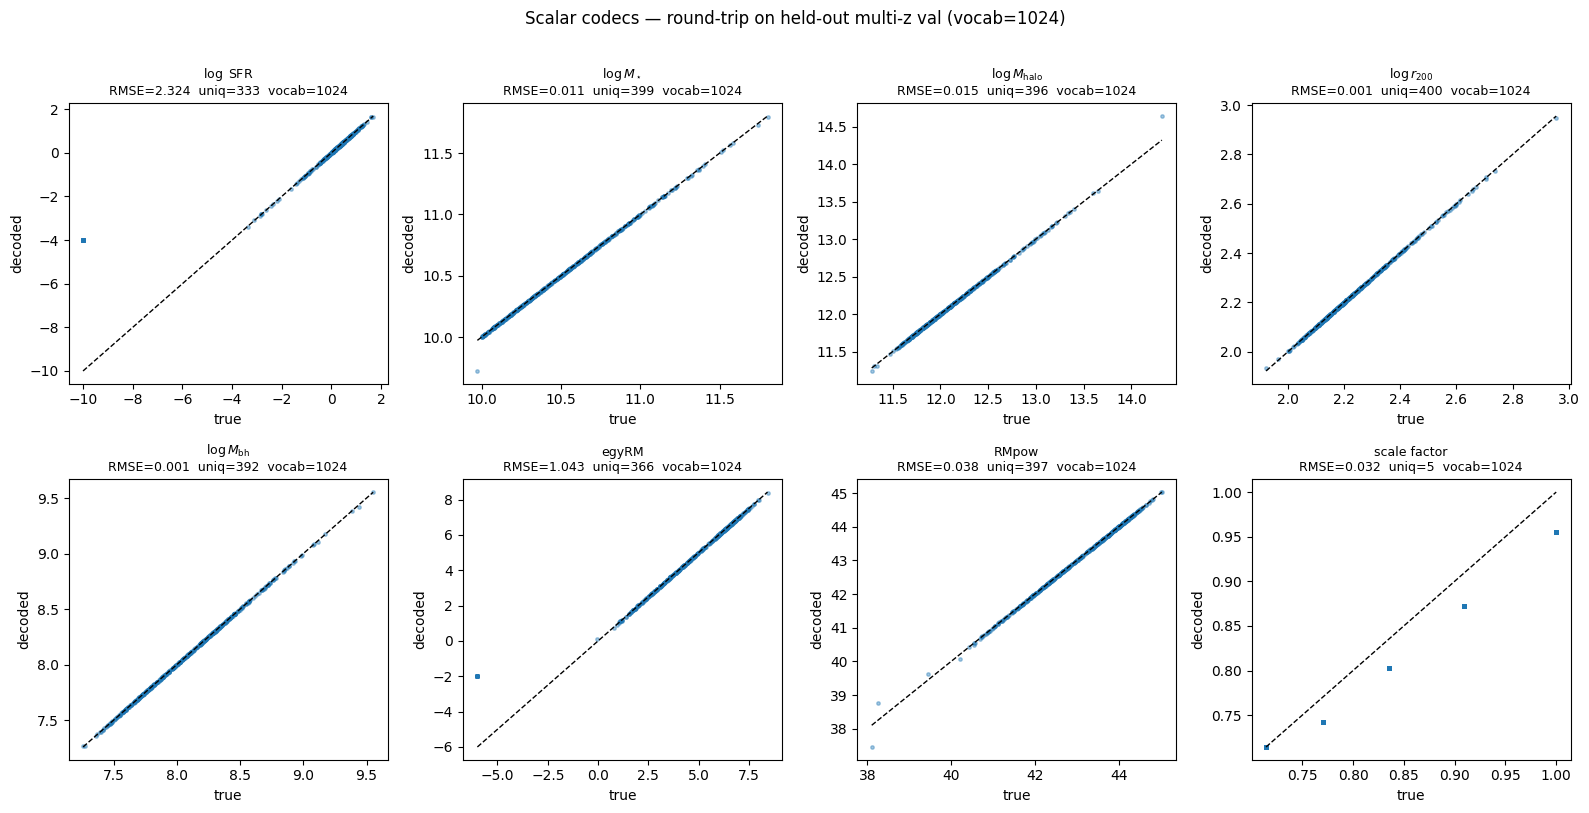

In [5]:
# Round-trip on the held-out VAL split: encode -> token -> decode, compare to truth.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (name, (mk, Mod, attr, lab)) in zip(axes.flat, scalar_specs.items()):
    v = getattr(val_ds, attr).unsqueeze(-1)
    tok = scalar_codecs[name].encode(Mod(value=v))
    rec = scalar_codecs[name].decode(tok).value.squeeze(-1)
    tru = v.squeeze(-1)
    ax.scatter(tru.numpy(), rec.numpy(), s=6, alpha=0.4)
    lo, hi = tru.min().item(), tru.max().item()
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    rmse = float(((tru - rec) ** 2).mean().sqrt())
    uniq = int(torch.unique(tok, dim=0).shape[0])
    ax.set_title(f"{lab}\nRMSE={rmse:.3f}  uniq={uniq}  vocab={scalar_codecs[name].quantizer.codebook_size}",
                 fontsize=9)
    ax.set_xlabel("true"); ax.set_ylabel("decoded")
fig.suptitle("Scalar codecs — round-trip on held-out multi-z val (vocab=1024)", y=1.01)
fig.tight_layout(); plt.show()

## Family B — 1-D sequences: star-formation history

The SFH is a smooth 24-point curve, so we use a small **1-D ConvNeXt VQ auto-encoder**
(`sim.codecs.sfh.SFHCodec`):

* `ConvNextEncoder1d` with a **stride-4 stem** reduces 24 timesteps → **6 latent
  positions**.
* A **Lookup-Free Quantizer (LFQ)** with `lfq_dim=10` → **codebook 2¹⁰ = 1024** turns
  each position into one integer. So the whole SFH = **6 tokens**.
* A transposed-conv decoder upsamples 6 → 24.

Only the SFR channel is encoded; the fixed time grid is a buffer restored on decode.
Training loss = `MSE(SFR) + 0.1 · LFQ_aux_loss` (same as
`sim.train_codecs.train_sfh_codec`).

In [6]:
from sim.codecs.sfh import SFHCodec

if TRAIN:
    codec = SFHCodec(); codec.set_time_grid(time_grid)
    sfh_hist = train_1d_codec(codec, train_ds.sfh, val_ds.sfh, SimSFH, SimSFH, EPOCHS_1D, "SFH")
else:
    print("TRAIN=False -> skipping training; loading the saved SFH checkpoint next.")

TRAIN=False -> skipping training; loading the saved SFH checkpoint next.


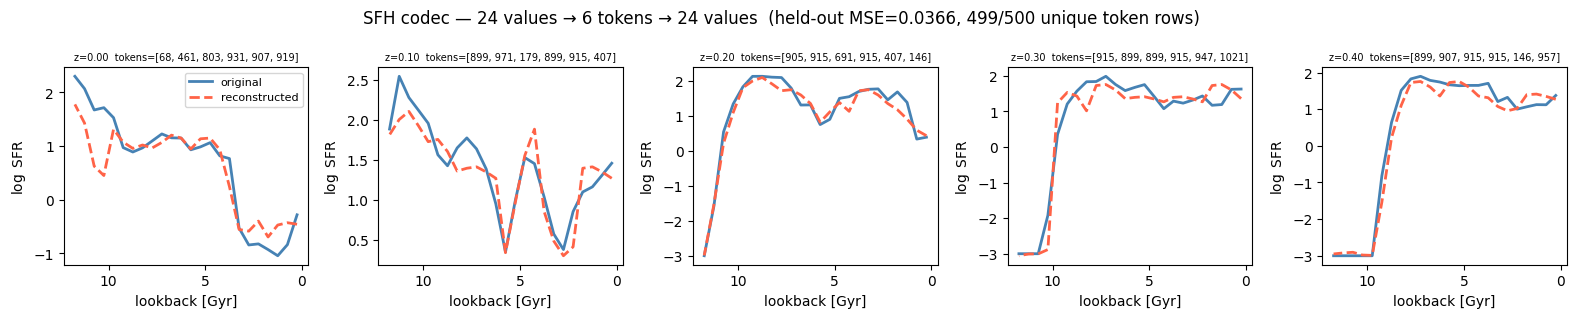

In [7]:
# Load the best checkpoint and reconstruct on the held-out multi-z val set.
sfh_codec = load_codec(SFHCodec(), SimSFH)
sfh_codec.set_time_grid(time_grid.to(DEVICE))

x = val_ds.sfh.to(DEVICE)
with torch.no_grad():
    tokens = sfh_codec.encode(SimSFH(value=x))
    recon  = sfh_codec.decode(tokens).value.cpu()
mse  = ((val_ds.sfh[:, 1:2] - recon[:, 1:2]) ** 2).mean().item()
uniq = int(torch.unique(tokens.cpu(), dim=0).shape[0])

fig, axes = plt.subplots(1, len(reps), figsize=(3.2 * len(reps), 3.2))
for ax, gi in zip(axes, reps):
    ax.plot(time_grid, val_ds.sfh[gi, 1], color="steelblue", lw=2, label="original")
    ax.plot(time_grid, recon[gi, 1],      color="tomato", lw=2, ls="--", label="reconstructed")
    ax.invert_xaxis(); ax.set_xlabel("lookback [Gyr]"); ax.set_ylabel(r"$\log$ SFR")
    ax.set_title(f"z={zred[gi]:.2f}  tokens={tokens[gi].tolist()}", fontsize=7)
axes[0].legend(fontsize=8)
fig.suptitle(f"SFH codec — 24 values → 6 tokens → 24 values  "
             f"(held-out MSE={mse:.4f}, {uniq}/{len(val_ds)} unique token rows)")
fig.tight_layout(); plt.show()

## Family B continued — Radial density profiles (gas & DM)

The profiles are 20-point curves and use the **same backbone** as the SFH codec
(`GasProfileCodec` / `DMProfileCodec`): a stride-4 stem → **5 tokens**, LFQ codebook
1024. Gas and DM each get their **own** codec because their shapes differ (a
declining DM cusp vs. a feedback-shaped gas profile).

Two design choices matter a lot here:

* **Standardize the log-density before the encoder.** `log10(ρ)` sits around −6.3
  with a spread of only ~0.75 dex. Feeding that raw offset into the conv stack
  wastes the codebook — a codec fed the raw values can collapse *every* DM profile
  onto a single code (a degenerate, uninformative tokenization). `codec.calibrate(
  train_profiles)` records the train-split mean/std, and the codec standardizes on
  encode and de-standardizes on decode. This alone takes gas reconstruction from
  MSE ≈ 0.044 to ≈ 0.003 and makes both gas and DM tokenizations diverse (≈ 500
  distinct token rows out of 500 validation galaxies).
* **A ConvNeXt block in the decoder.** One extra residual block gives the decoder
  enough capacity to trace the curved profile instead of a piecewise-flat
  approximation.

Encode only the density channel; the fixed `r/r200` grid is a buffer restored on
decode.

In [8]:
from sim.codecs.profile import GasProfileCodec, DMProfileCodec

if TRAIN:
    # calibrate() sets the log-density standardization stats (mean/std over the
    # TRAIN split) so the encoder sees a zero-mean, unit-variance signal — this
    # is what lets the LFQ actually use its codebook (see the note above).
    c = GasProfileCodec(); c.set_radius_grid(radius_grid); c.calibrate(train_ds.gas_prof)
    train_1d_codec(c, train_ds.gas_prof, val_ds.gas_prof, SimGasProfile, SimGasProfile, EPOCHS_1D, "gas-prof")
    c = DMProfileCodec(); c.set_radius_grid(radius_grid); c.calibrate(train_ds.dm_prof)
    train_1d_codec(c, train_ds.dm_prof, val_ds.dm_prof, SimDMProfile, SimDMProfile, EPOCHS_1D, "dm-prof")
else:
    print("TRAIN=False -> skipping training; loading the saved profile checkpoints next.")

TRAIN=False -> skipping training; loading the saved profile checkpoints next.


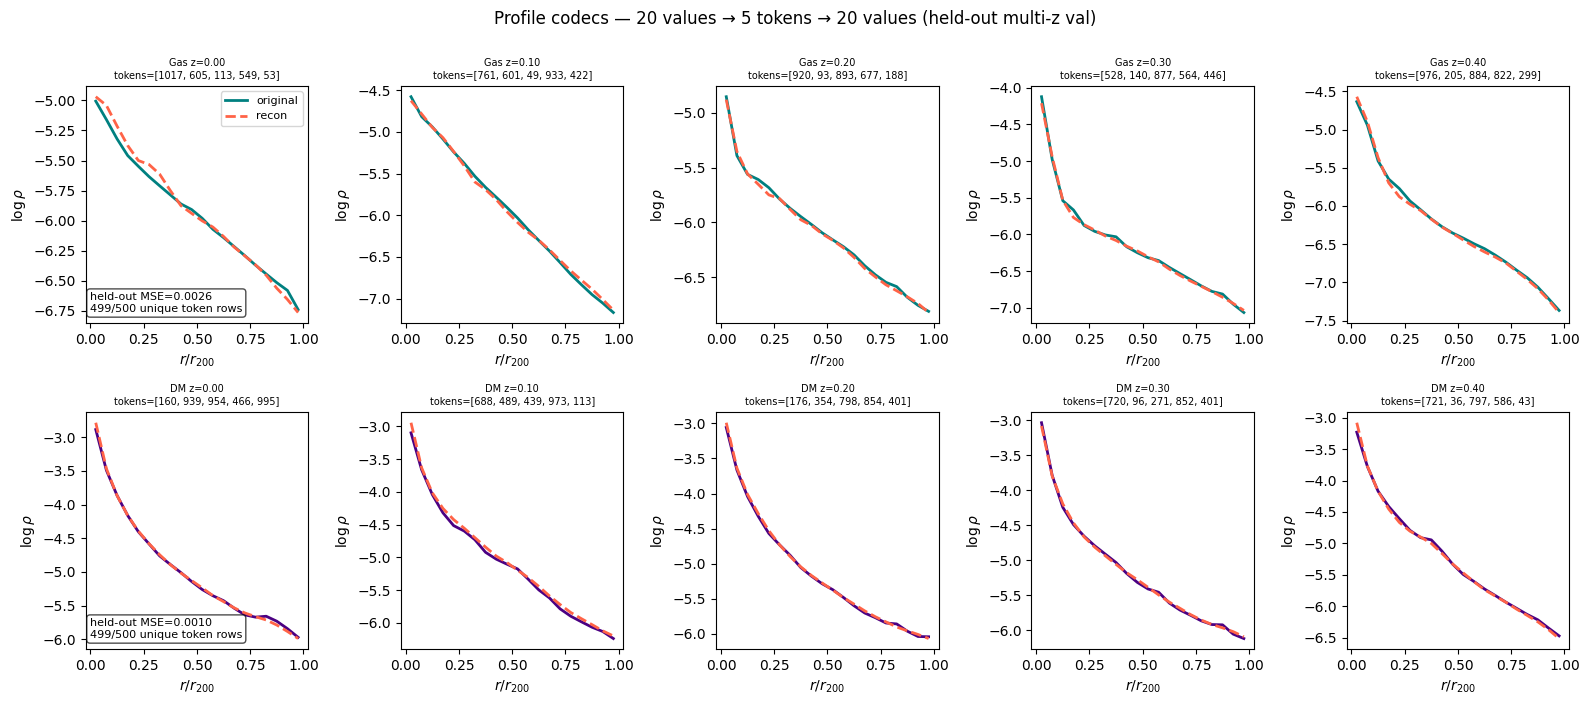

In [9]:
gas_codec = load_codec(GasProfileCodec(), SimGasProfile); gas_codec.set_radius_grid(radius_grid.to(DEVICE))
dm_codec  = load_codec(DMProfileCodec(),  SimDMProfile);  dm_codec.set_radius_grid(radius_grid.to(DEVICE))

n_show = len(reps)
fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 7))
for row, (codec, field, Mod, lab, color) in enumerate([
        (gas_codec, "gas_prof", SimGasProfile, "Gas", "teal"),
        (dm_codec,  "dm_prof",  SimDMProfile,  "DM",  "indigo")]):
    # whole held-out split: reconstruction MSE + token diversity
    xv = getattr(val_ds, field).to(DEVICE)
    with torch.no_grad():
        tokv = codec.encode(Mod(value=xv))
        recv = codec.decode(tokv).value.cpu()
    mse_all = ((getattr(val_ds, field)[:, 1] - recv[:, 1]) ** 2).mean().item()
    n_uniq  = int(torch.unique(tokv.cpu(), dim=0).shape[0])
    for j, gi in enumerate(reps):
        ax = axes[row][j]
        ax.plot(radius_grid, getattr(val_ds, field)[gi, 1], color=color, lw=2, label="original")
        ax.plot(radius_grid, recv[gi, 1],                    color="tomato", lw=2, ls="--", label="recon")
        ax.set_xlabel(r"$r/r_{200}$"); ax.set_ylabel(r"$\log\rho$")
        ax.set_title(f"{lab} z={zred[gi]:.2f}\ntokens={tokv[gi].cpu().tolist()}", fontsize=7)
        if j == 0 and row == 0: ax.legend(fontsize=8)
    axes[row][0].text(0.02, 0.04,
                      f"held-out MSE={mse_all:.4f}\n{n_uniq}/{len(val_ds)} unique token rows",
                      transform=axes[row][0].transAxes, fontsize=8, va="bottom",
                      bbox=dict(boxstyle="round", fc="white", alpha=0.7))
fig.suptitle("Profile codecs — 20 values → 5 tokens → 20 values (held-out multi-z val)", y=1.0)
fig.tight_layout(); plt.show()

## Family A — 2-D image: galaxy face-on

The image carries far more information, so it gets a **MagVit-style convolutional VQ
auto-encoder** (`sim.codecs.image.SimGalaxyImageCodec`):

* `MagVitAE` encoder with `n_compressions=2` → 128/4 = **32×32 latent grid** = **1024
  tokens**.
* A **Finite Scalar Quantizer (FSQ)** with `levels=[5,5,5,5]` → vocab **5⁴ = 625**.
  FSQ rounds each of 4 latent channels to one of 5 levels — no learned codebook, no
  collapse.
* A symmetric decoder reconstructs the `(8, 128, 128)` image.

This is the expensive one — `EPOCHS_IMG` passes over the training galaxies on a **GPU**
(this cell is skipped on the CPU load pass). The training step is exactly
`sim.train_codecs.train_star_image_codec`'s:

```python
z = codec._encode(SimGalaxyImage(flux=img, bands=SIM_BANDS))
z_q, _, _ = codec.quantizer(z)
x_hat = codec._decode(z_q)
loss = F.mse_loss(x_hat.flux, img)   # + backprop
```

In [10]:
from sim.codecs.image import SimGalaxyImageCodec

if TRAIN:
    img_hist = train_image_codec(SimGalaxyImageCodec(), dataset.star_img,
                                 SimGalaxyImage, EPOCHS_IMG, "galaxy-image")
else:
    print("TRAIN=False -> skipping GPU training; loading the saved galaxy-image checkpoint next.")

TRAIN=False -> skipping GPU training; loading the saved galaxy-image checkpoint next.


token tensor: (5, 1024) torch.int32 range [ 1 , 624 ] of vocab 625


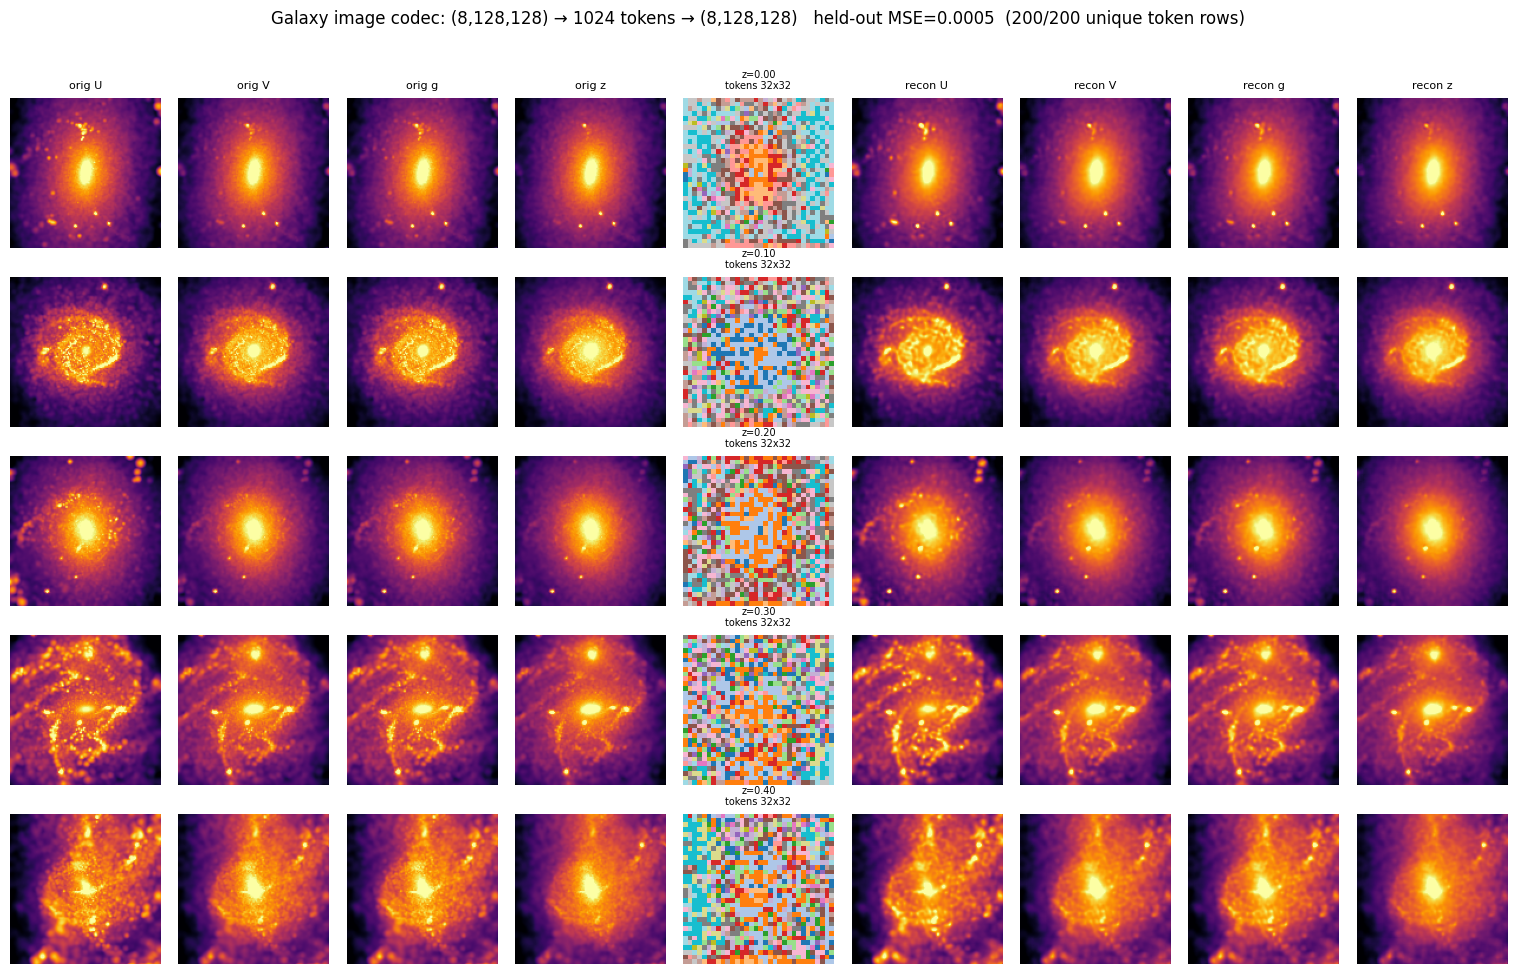

In [11]:
# Load the best checkpoint, encode held-out galaxies, show the 32x32 token grid, decode.
def stretch(im):
    lo, hi = np.percentile(im, 1), np.percentile(im, 99)
    return np.clip((im - lo) / max(hi - lo, 1e-6), 0, 1)

BAND_NAMES = ["U", "B", "V", "K", "g", "r", "i", "z"]
star_codec = load_codec(SimGalaxyImageCodec(), SimGalaxyImage)

# held-out reconstruction MSE + token diversity over a 200-image subset
idx = torch.arange(min(200, len(val_ds)))
se = 0.0; toks = []
with torch.no_grad():
    for i in range(0, len(idx), 16):
        b = val_ds.star_img[idx[i:i+16]].to(DEVICE)
        t = star_codec.encode(SimGalaxyImage(flux=b, bands=SIM_BANDS)); toks.append(t.cpu())
        se += ((star_codec.decode(t).flux - b) ** 2).sum().item()
img_mse  = se / (len(idx) * 8 * 128 * 128)
img_uniq = int(torch.unique(torch.cat(toks), dim=0).shape[0])

vsel = reps
imgs = val_ds.star_img[vsel].to(DEVICE)
with torch.no_grad():
    tokens = star_codec.encode(SimGalaxyImage(flux=imgs, bands=SIM_BANDS))   # (n, 1024)
    recon  = star_codec.decode(tokens).flux.cpu()
imgs = imgs.cpu()
print("token tensor:", tuple(tokens.shape), tokens.dtype,
      "range [", int(tokens.min()), ",", int(tokens.max()), "] of vocab",
      int(star_codec.quantizer.codebook_size))

show_bands = [0, 2, 4, 7]   # U, V, g, z
ncol = len(show_bands)*2 + 1; n_show = len(vsel)
fig, axes = plt.subplots(n_show, ncol, figsize=(ncol*1.7, n_show*1.9))
for gi in range(n_show):
    for ci, b in enumerate(show_bands):
        axes[gi][ci].imshow(stretch(imgs[gi, b].numpy()), cmap="inferno", origin="lower")
        axes[gi][ci].axis("off")
        if gi == 0: axes[gi][ci].set_title(f"orig {BAND_NAMES[b]}", fontsize=8)
    axt = axes[gi][len(show_bands)]
    axt.imshow(tokens[gi].reshape(32, 32).cpu().numpy(), cmap="tab20"); axt.axis("off")
    axt.set_title(f"z={zred[vsel[gi]]:.2f}\ntokens 32x32", fontsize=7)
    for ci, b in enumerate(show_bands):
        axes[gi][len(show_bands)+1+ci].imshow(stretch(recon[gi, b].numpy()), cmap="inferno", origin="lower")
        axes[gi][len(show_bands)+1+ci].axis("off")
        if gi == 0: axes[gi][len(show_bands)+1+ci].set_title(f"recon {BAND_NAMES[b]}", fontsize=8)
fig.suptitle(f"Galaxy image codec: (8,128,128) → 1024 tokens → (8,128,128)   "
             f"held-out MSE={img_mse:.4f}  ({img_uniq}/{len(idx)} unique token rows)", y=1.02)
fig.tight_layout(); plt.show()

## Putting it together — a token dictionary

The transformer (Tutorial 2) consumes a **dict of integer token tensors**, one entry per
modality, all sharing the galaxy (batch) axis. Below we tokenize a held-out batch with
the trained codecs — exactly what `sim.train_codecs.tokenize_dataset` does for the full
dataset before transformer training. All **12 modalities** (image, SFH, gas/DM profile,
and the 8 scalars) go into one dict.

In [12]:
N_TOK = min(N_TOK, len(val_ds))

@torch.no_grad()
def encode_images(codec, field, make_mod, bs=16):
    X = getattr(val_ds, field)[:N_TOK]
    return torch.cat([codec.encode(make_mod(X[i:i+bs].to(DEVICE))).cpu()
                      for i in range(0, len(X), bs)], dim=0)

tokens = {
    "tok_sim_galaxy_image": encode_images(star_codec, "star_img",
                                          lambda xb: SimGalaxyImage(flux=xb, bands=SIM_BANDS)),
    "tok_sim_sfh":         sfh_codec.encode(SimSFH(value=val_ds.sfh[:N_TOK].to(DEVICE))).cpu(),
    "tok_sim_gas_profile": gas_codec.encode(SimGasProfile(value=val_ds.gas_prof[:N_TOK].to(DEVICE))).cpu(),
    "tok_sim_dm_profile":  dm_codec.encode(SimDMProfile(value=val_ds.dm_prof[:N_TOK].to(DEVICE))).cpu(),
}
for name, (mk, Mod, attr, lab) in scalar_specs.items():
    tokens[f"tok_{name}"] = scalar_codecs[name].encode(
        Mod(value=getattr(val_ds, attr)[:N_TOK].unsqueeze(-1))).cpu()

print(f"{'modality':24s} {'shape':>14s} {'max+1':>7s}")
for k, v in tokens.items():
    print(f"{k:24s} {str(tuple(v.shape)):>14s} {int(v.max())+1:>7d}")
torch.save(tokens, os.path.join(SAVE_DIR, "tokens_demo.pt"))
print(f"\nsaved -> {SAVE_DIR}/tokens_demo.pt   |   "
      f"{sum(v.shape[1] for v in tokens.values())} tokens per galaxy")

modality                          shape   max+1
tok_sim_galaxy_image         (64, 1024)     625
tok_sim_sfh                     (64, 6)    1002
tok_sim_gas_profile             (64, 5)    1022
tok_sim_dm_profile              (64, 5)     974
tok_sim_sfr                     (64, 1)    1011
tok_sim_mstar                   (64, 1)    1006
tok_sim_mhalo                   (64, 1)    1007
tok_sim_r200                    (64, 1)    1011
tok_sim_mbh                     (64, 1)    1005
tok_sim_egyRM                   (64, 1)    1007
tok_sim_RMpow                   (64, 1)    1022
tok_sim_redshift                (64, 1)       1

saved -> checkpoints_multiz/tokens_demo.pt   |   1048 tokens per galaxy


## From codec tokens to transformer inputs

Every codec above ends at the **same interface: a 2-D tensor of integers `(B, N)`** —
`B` galaxies, `N` tokens for that modality. That integer is the *only* thing passed on to
Tutorial 2. Everything inside the codec (its codebook, its auto-encoder latent space)
stays behind — the transformer never sees it.

What differs between modalities is just the number of tokens `N` and the vocabulary `V`:

| modality | tokens `N` | codec codebook | transformer embedding `V` | codec quantizer |
|---|---:|---:|---:|---|
| `tok_sim_galaxy_image` | 1024 (32×32) | 625 | 625 | MagVit + FSQ |
| `tok_sim_sfh` | 6 | 1024 | 1024 | ConvNeXt + LFQ |
| `tok_sim_gas_profile` / `tok_sim_dm_profile` | 5 | 1024 | 1024 | ConvNeXt + LFQ |
| `tok_sim_*` scalars (×8) | 1 | 1024 | 4096 | reservoir-CDF |

The scalar codecs emit tokens in `[0, 1024)`, but the transformer keeps a larger
vocab-**4096** embedding table for the scalar slots (a harmless superset
of the codec codebook). The transformer reconciles the per-modality differences in two
steps — both done **inside the FourM model, not the codec**:

1. **Per-modality embedding `(B, N) → (B, N, D)`.** Each modality owns a *learned*
   `nn.Embedding(V, D)` that maps its integer IDs into the shared transformer width `D`
   (e.g. 384). A vocab-625 table and a vocab-4096 table both emit `D`-dim vectors, so after
   this step every modality lives in the *same* space.
2. **Concatenation `→ (B, O, D)`.** The per-modality sequences are stacked along the token
   axis into one sequence of length `O = ΣN`. A learned *modality embedding* + a positional
   embedding are added so the transformer can still tell which token came from which
   modality and in which position.

**The codec codebook and the transformer embedding are completely separate tables** — they
share only the integer index:

| | codec codebook (Tutorial 1) | transformer `token_emb` (Tutorial 2) |
|---|---|---|
| what it is | fixed / derived buffer (FSQ, LFQ) or CDF | learned `nn.Embedding(V, D)` |
| maps | index → codec latent (`log₂V` dims) | index → transformer vector (`D` dims) |
| trained | here, then **frozen** | during transformer training |
| in this notebook's checkpoints? | yes | no |

So the integer `7` means "this latent cell" to the codec and "look up row 7 of my learned
table" to the transformer — two unrelated vectors that happen to share an index.

The cell below runs the token dict we just built through the **actual** FourM encoder
embeddings, to make the `(B, N) → (B, N, D) → (B, O, D)` flow concrete.

In [13]:
import torch
from sim.modality_info import SIM_MODALITY_INFO

D = 384  # transformer width for the "tiny" model — the SAME D for every modality

# One learned embedding table per modality, initialised at width D.
# This is exactly what FourM.__init__ constructs (and trains) in Tutorial 2.
enc_emb = {k: SIM_MODALITY_INFO[k]["encoder_embedding"]() for k in tokens}
for m in enc_emb.values():
    m.init(dim_tokens=D)

print(f"{'modality':24s} {'tokens (B,N)':>13s} -> {'embedded (B,N,D)':>17s}   V")
embedded = {}
for k, v in tokens.items():
    # forward() looks up the per-modality nn.Embedding: (B, N) integers -> (B, N, D) vectors
    embedded[k] = enc_emb[k]({"tensor": v.long()})["x"]
    print(f"{k:24s} {str(tuple(v.shape)):>13s} -> "
          f"{str(tuple(embedded[k].shape)):>17s}   {SIM_MODALITY_INFO[k]['vocab_size']}")

# Stack every modality along the token axis -> a single sequence for the transformer
seq = torch.cat([embedded[k] for k in tokens], dim=1)   # (B, O, D),  O = sum of all N
print(f"\nconcatenated -> {tuple(seq.shape)}   "
      f"(O = {seq.shape[1]} tokens/galaxy at shared width D = {D})")

modality                  tokens (B,N) ->  embedded (B,N,D)   V
tok_sim_galaxy_image        (64, 1024) ->   (64, 1024, 384)   625
tok_sim_sfh                    (64, 6) ->      (64, 6, 384)   1024
tok_sim_gas_profile            (64, 5) ->      (64, 5, 384)   1024
tok_sim_dm_profile             (64, 5) ->      (64, 5, 384)   1024
tok_sim_sfr                    (64, 1) ->      (64, 1, 384)   4096
tok_sim_mstar                  (64, 1) ->      (64, 1, 384)   4096
tok_sim_mhalo                  (64, 1) ->      (64, 1, 384)   4096
tok_sim_r200                   (64, 1) ->      (64, 1, 384)   4096
tok_sim_mbh                    (64, 1) ->      (64, 1, 384)   4096
tok_sim_egyRM                  (64, 1) ->      (64, 1, 384)   4096
tok_sim_RMpow                  (64, 1) ->      (64, 1, 384)   4096
tok_sim_redshift               (64, 1) ->      (64, 1, 384)   4096

concatenated -> (64, 1048, 384)   (O = 1048 tokens/galaxy at shared width D = 384)


## Summary

* **Scalars** (×8: sfr, mstar, mhalo, r200, mbh, egyRM, RMpow, redshift) → quantile
  quantizer → 1 ordinal token each (near-lossless; calibrated on the training
  split, no GPU).
* **1-D curves** (SFH, gas/DM profiles) → ConvNeXt VQ-AE + LFQ → 5–6 tokens each.
* **2-D image** (galaxy face-on) → MagVit VQ-AE + FSQ → 1024 tokens.

Each neural codec was **trained** on the full multi-redshift set
(`GAL4M_TRAIN=1`, on a GPU), its **best** checkpoint (lowest held-out validation
MSE) saved to `checkpoints/codecs/<modality>/`, and the reconstructions above were
produced by **loading** those checkpoints and decoding the held-out 500-galaxy
validation set. The star-image normalization is a **fixed** constant
(`img_norm.json`) shared by training, validation, and tokenization.

**To (re)train:** `python -m sim.train_codecs` runs over all five snapshots with
best-by-validation checkpoint selection, scalar codebook 1024, and the gas/DM
profile `calibrate()` standardization (~3 h on one V100).

➡️ Next: train the multimodal transformer on these tokens
(**`tutorial-2-transformer.ipynb`**).